In [1]:
#dep
# from functools import partial
# from transform_specto import TransformSpecto as TS
# C,R = (0,1)

# labels = {0,1,2,3,4,5,6,7,8}
# pre_process = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
# features_extract = [
#     partial(TS.mean, axis=C),   partial(TS.mean, axis=R),
#     partial(TS.std, axis=C),    partial(TS.std, axis=R),
#     partial(TS.median, axis=C), partial(TS.median, axis=R),
#     partial(TS.min, axis=C),    partial(TS.min, axis=R),
#     partial(TS.max, axis=C),    partial(TS.max, axis=R),
#     partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
#     partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R)]
# normalize = [TS.norm0to1]
# ts = TS(variant=TS.VARIANT_STANDARD, pre_process=pre_process, features_extract=features_extract, normalize=normalize)
# ts.populate()
# ts.save()
# print("done")

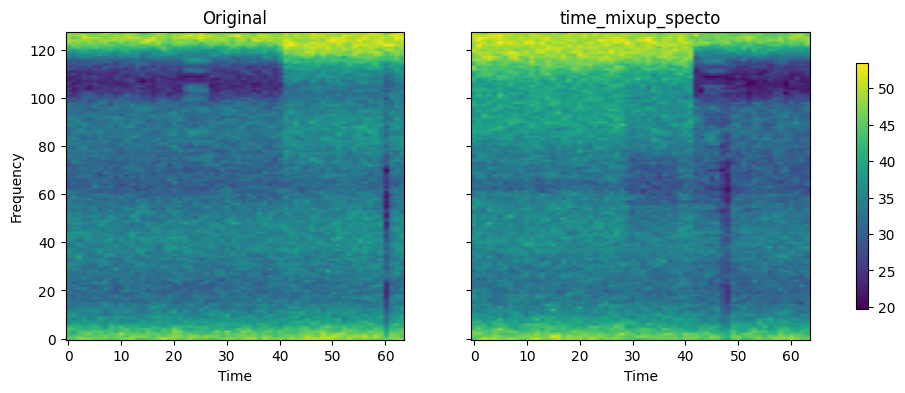

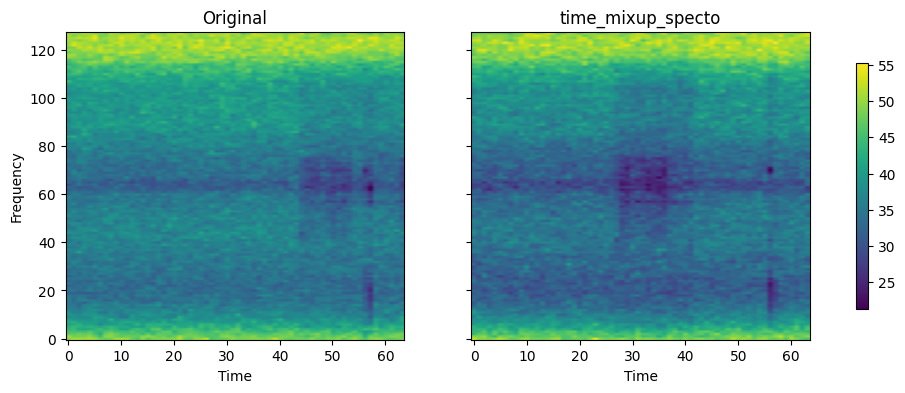

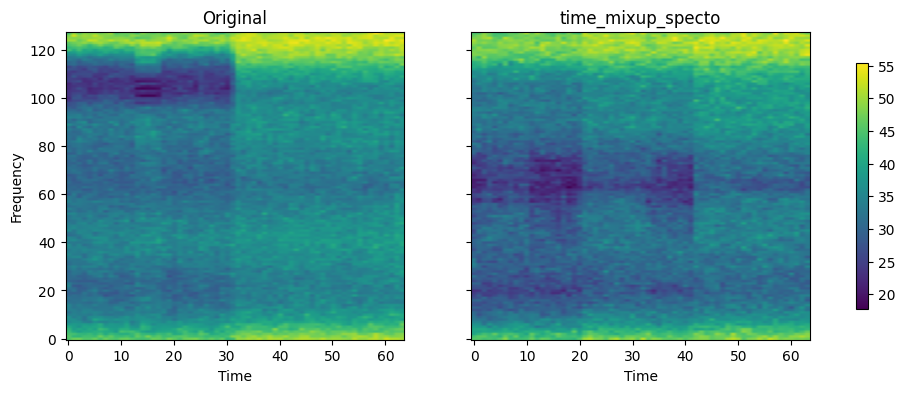

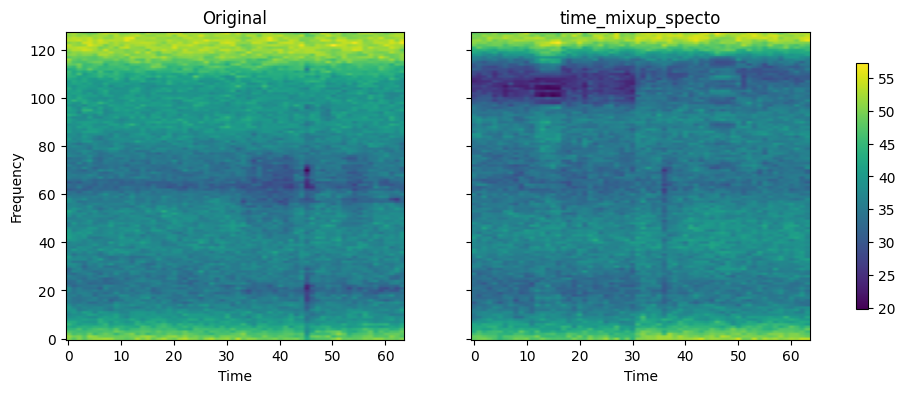

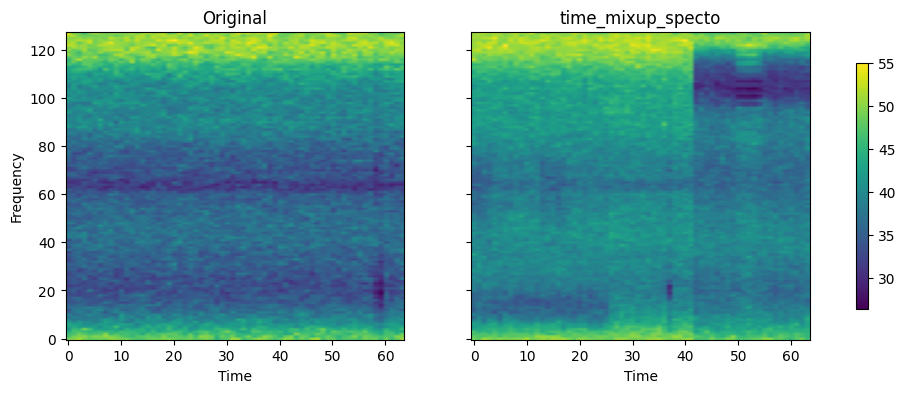

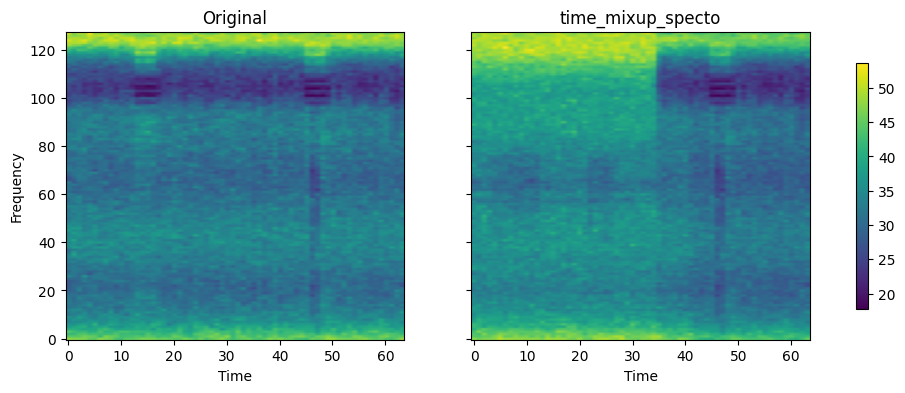

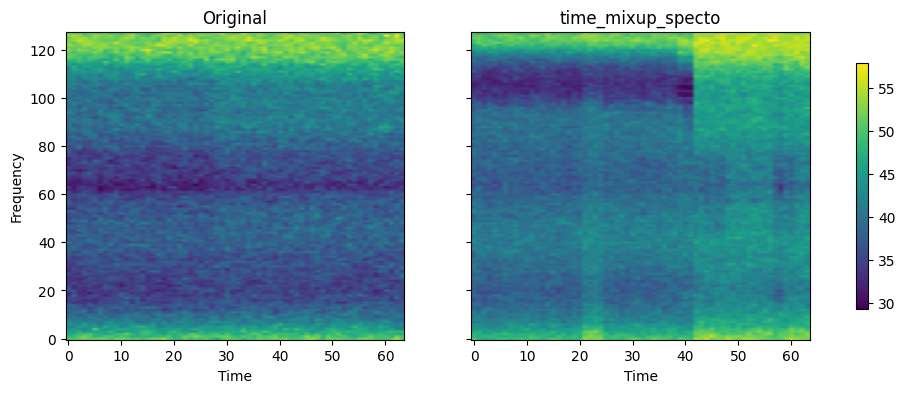

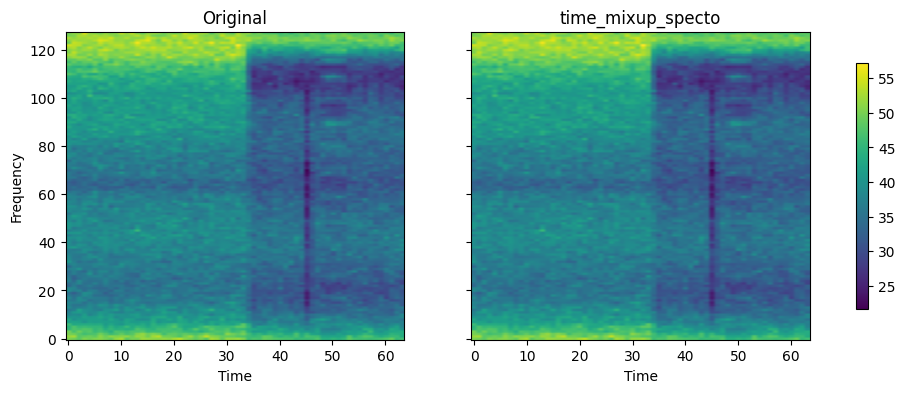

8/8
saving to: my_data/augment_class3_10times_with_time_mixup
done


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
KeyboardInterrupt


In [2]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "augment_class3_10times_with_time_mixup"
labels = {3}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = [partial(TS.time_mixup_specto, display_sample=True)]
features_extract = [
    partial(TS.mean, axis=C),   partial(TS.mean, axis=R),
    partial(TS.std, axis=C),    partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R)]

transform_train = TS(is_test=False, include_labels=labels, times=10, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=None)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
print("done")



In [2]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = [partial(TS.time_mixup_specto, display_sample=False)]
features_extract = [
    partial(TS.mean, axis=C),   partial(TS.mean, axis=R),
    partial(TS.std, axis=C),    partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R)]

label_times = [
    # ({1}, 1),
    ({3}, 20),
    # ({4}, 15),
    # ({5}, 15),
    # ({6}, 15),
    # ({7}, 15),
    # ({8}, 15),
]

for labels, times in label_times:
    label_str = "_".join(str(l) for l in sorted(labels))
    foldername = f"augment_class{label_str}_{times}times_with_time_mixup"
    transform_train = TS(
        is_test=False,
        include_labels=labels,
        times=times,
        pre_process_funcs=pre_process_funcs,
        augment_funcs=augment_funcs,
        features_extract_funcs=features_extract,
        batchsize=64
    )
    transform_train.populate_df()
    TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=None)
    transform_train.save_df(foldername=foldername)
    transform_train.save_description(foldername=foldername)
    print("done", labels, "folder:", foldername)


15/15
saving to: my_data/augment_class3_20times_with_time_mixup
done {3} folder: augment_class3_20times_with_time_mixup


In [3]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "standard2"
labels = {0,1,2,3,4,5,6,7,8}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = []
features_extract = [
    partial(TS.mean, axis=C),   partial(TS.mean, axis=R),
    partial(TS.std, axis=C),    partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R),
    partial(TS.iqr, axis=C), partial(TS.iqr, axis=R)]

transform_train = TS(is_test=False, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
transform_test = TS(is_test=True, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_test.populate_df()
TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=transform_test)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
transform_test.save_df(foldername=foldername)
print("done")

202/202
52/52
saving to: my_data/standard2
saving to: my_data/standard2
done


In [1]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "standard2_no_norm"
labels = {0,1,2,3,4,5,6,7,8}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = []
features_extract = [
    partial(TS.mean, axis=C),   partial(TS.mean, axis=R),
    partial(TS.std, axis=C),    partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R),
    partial(TS.iqr, axis=C), partial(TS.iqr, axis=R)]

transform_train = TS(is_test=False, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
transform_test = TS(is_test=True, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_test.populate_df()
TS.normalize(func=TS.no_norm, transform_train=transform_train, transform_test=transform_test)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
transform_test.save_df(foldername=foldername)
print("done")

202/202
52/52
saving to: my_data/standard2_no_norm
saving to: my_data/standard2_no_norm
done


In [1]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "standard3"
labels = {0,1,2,3,4,5,6,7,8}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = []
features_extract = [
                                partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R),
    partial(TS.iqr, axis=C), partial(TS.iqr, axis=R)]

transform_train = TS(is_test=False, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
transform_test = TS(is_test=True, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_test.populate_df()
TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=transform_test)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
transform_test.save_df(foldername=foldername)
print("done")

202/202
52/52
saving to: my_data/standard3
saving to: my_data/standard3
done


In [1]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "full64x64specto"
labels = {0,1,2,3,4,5,6,7,8}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(64,64))]
augment_funcs = []
features_extract = [TS.flat_specto]

transform_train = TS(is_test=False, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
transform_test = TS(is_test=True, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_test.populate_df()
TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=transform_test)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
transform_test.save_df(foldername=foldername)
print("done")

202/202
52/52
saving to: my_data/full64x64specto
saving to: my_data/full64x64specto
done


In [1]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "standard4"
labels = {0,1,2,3,4,5,6,7,8}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = []
features_extract = [
                                partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R),
    partial(TS.percentile, p=75, axis=C), partial(TS.percentile, p=75, axis=R),
    partial(TS.percentile, p=25, axis=C), partial(TS.percentile, p=25, axis=R)]

transform_train = TS(is_test=False, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
transform_test = TS(is_test=True, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_test.populate_df()
TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=transform_test)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
transform_test.save_df(foldername=foldername)
print("done")

202/202
52/52
saving to: my_data/standard4
saving to: my_data/standard4
done


In [2]:
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "standard5"
labels = {0,1,2,3,4,5,6,7,8}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = []
features_extract = [
                                partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R),
    partial(TS.percentile, p=75, axis=C), partial(TS.percentile, p=75, axis=R),
    partial(TS.percentile, p=25, axis=C), partial(TS.percentile, p=25, axis=R),
    partial(TS.percentile, p=90, axis=C), partial(TS.percentile, p=90, axis=R),
    partial(TS.percentile, p=10, axis=C), partial(TS.percentile, p=10, axis=R)]

transform_train = TS(is_test=False, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
transform_test = TS(is_test=True, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_test.populate_df()
TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=transform_test)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
transform_test.save_df(foldername=foldername)
print("done")

202/202
52/52
saving to: my_data/standard5
saving to: my_data/standard5
done


In [2]:
## super features
from functools import partial
from transform_specto import TransformSpecto as TS
C,R = (0,1)

foldername = "superfeatures1"
labels = {0,1,2,3,4,5,6,7,8}
pre_process_funcs = [TS.flip_specto, partial(TS.resize_specto, shape=(128,64))]
augment_funcs = []
features_extract = [
    partial(TS.mean, axis=C),   partial(TS.mean, axis=R),
    partial(TS.std, axis=C),    partial(TS.std, axis=R),
    partial(TS.median, axis=C), partial(TS.median, axis=R),
    partial(TS.min, axis=C),    partial(TS.min, axis=R),
    partial(TS.max, axis=C),    partial(TS.max, axis=R),
    partial(TS.minloc, axis=C), partial(TS.minloc, axis=R),
    partial(TS.maxloc, axis=C), partial(TS.maxloc, axis=R),
    partial(TS.percentile, p=75, axis=C), partial(TS.percentile, p=75, axis=R),
    partial(TS.percentile, p=25, axis=C), partial(TS.percentile, p=25, axis=R),
    partial(TS.percentile, p=90, axis=C), partial(TS.percentile, p=90, axis=R),
    partial(TS.percentile, p=10, axis=C), partial(TS.percentile, p=10, axis=R)]

transform_train = TS(is_test=False, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_train.populate_df()
transform_test = TS(is_test=True, include_labels=labels, times=1, pre_process_funcs=pre_process_funcs, augment_funcs=augment_funcs, features_extract_funcs=features_extract, batchsize=64)
transform_test.populate_df()
TS.normalize(func=TS.norm0to1, transform_train=transform_train, transform_test=transform_test)
transform_train.save_df(foldername=foldername)
transform_train.save_description(foldername=foldername)
transform_test.save_df(foldername=foldername)
print("done")

202/202
52/52
saving to: my_data/superfeatures1
saving to: my_data/superfeatures1
done
